In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import chi2

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
train = pd.read_csv("thyroid-diag/sick.data", header=None)
test = pd.read_csv("thyroid-diag/sick.test", header=None)

In [4]:
columns = [
'age','sex','on_thyroxine','query_on_thyroxine','on_antithyroid_medication',
'sick_flag','pregnant','thyroid_surgery','I131_treatment','query_hypothyroid',
'query_hyperthyroid','lithium','goitre','tumor','hypopituitary','psych',
'TSH_measured','TSH','T3_measured','T3','TT4_measured','TT4',
'T4U_measured','T4U','FTI_measured','FTI','TBG_measured','TBG',
'referral_source','target'
]

train.columns = columns
test.columns = columns

In [5]:
train = train.drop(columns=['TBG','TBG_measured'])
test = test.drop(columns=['TBG','TBG_measured'])

In [6]:
train.replace("?", np.nan, inplace=True)
test.replace("?", np.nan, inplace=True)

In [7]:
train['target'] = train['target'].str.split('.').str[0]
test['target'] = test['target'].str.split('.').str[0]

In [8]:
numeric_cols = ['age','TSH','T3','TT4','T4U','FTI']

for col in numeric_cols:
    train[col] = pd.to_numeric(train[col], errors='coerce')
    test[col] = pd.to_numeric(test[col], errors='coerce')

In [9]:
for col in numeric_cols:
    train[col] = train[col].fillna(train[col].median())
    test[col] = test[col].fillna(test[col].median())

In [10]:
categorical_cols = train.select_dtypes(include='object').columns

for col in categorical_cols:
    train[col] = train[col].fillna(train[col].mode()[0])
    test[col] = test[col].fillna(test[col].mode()[0])

In [11]:
le = LabelEncoder()

for col in train.columns:
    if train[col].dtype == 'object':
        train[col] = le.fit_transform(train[col])
        test[col] = le.transform(test[col])

In [12]:
X_train = train.drop('target', axis=1)
y_train = train['target']

X_test = test.drop('target', axis=1)
y_test = test['target']

In [13]:
chi_scores, p_values = chi2(X_train, y_train)

feature_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'Score': chi_scores
})

print(feature_scores.sort_values(by='Score', ascending=False))

                      Feature       Score
0                         age  530.043967
21                        TT4  352.957705
19                         T3  110.185019
5                   sick_flag   20.179940
14              hypopituitary   15.374269
9           query_hypothyroid   10.796240
2                on_thyroxine   10.586381
18                T3_measured    8.955824
25                        FTI    6.657294
23                        T4U    4.547855
1                         sex    4.250914
10         query_hyperthyroid    3.122262
13                      tumor    2.733642
6                    pregnant    2.666793
7             thyroid_surgery    2.536706
26            referral_source    2.396459
4   on_antithyroid_medication    2.211487
16               TSH_measured    1.631970
8              I131_treatment    1.355331
22               T4U_measured    1.202655
24               FTI_measured    1.179455
3          query_on_thyroxine    1.057125
20               TT4_measured    0

In [14]:
mean_score = feature_scores['Score'].mean()

selected_features = feature_scores[feature_scores['Score'] > mean_score]['Feature']

print("\nSelected Features:")
print(selected_features)

X_train = X_train[selected_features]
X_test = X_test[selected_features]


Selected Features:
0     age
19     T3
21    TT4
Name: Feature, dtype: object


In [15]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_train).value_counts())

After SMOTE:
target
0    2629
1    2629
Name: count, dtype: int64


/Users/sparshkarna/dev/sem6/ml-lab/myenv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [17]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", acc_lr)

Logistic Regression Accuracy: 0.8858024691358025


In [18]:
nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

acc_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", acc_nb)

Naive Bayes Accuracy: 0.8641975308641975


In [19]:
svm = SVC(kernel='rbf', C=10, gamma=0.1)

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", acc_svm)

SVM Accuracy: 0.9259259259259259


In [20]:
print("\nLogistic Regression Report")
print(classification_report(y_test, y_pred_lr))

print("\nNaive Bayes Report")
print(classification_report(y_test, y_pred_nb))

print("\nSVM Report")
print(classification_report(y_test, y_pred_svm))


Logistic Regression Report
              precision    recall  f1-score   support

           0       1.00      0.88      0.94       912
           1       0.35      0.97      0.51        60

    accuracy                           0.89       972
   macro avg       0.67      0.92      0.72       972
weighted avg       0.96      0.89      0.91       972


Naive Bayes Report
              precision    recall  f1-score   support

           0       0.99      0.86      0.92       912
           1       0.30      0.92      0.45        60

    accuracy                           0.86       972
   macro avg       0.65      0.89      0.69       972
weighted avg       0.95      0.86      0.89       972


SVM Report
              precision    recall  f1-score   support

           0       1.00      0.92      0.96       912
           1       0.45      0.95      0.61        60

    accuracy                           0.93       972
   macro avg       0.72      0.94      0.79       972
weighted avg  

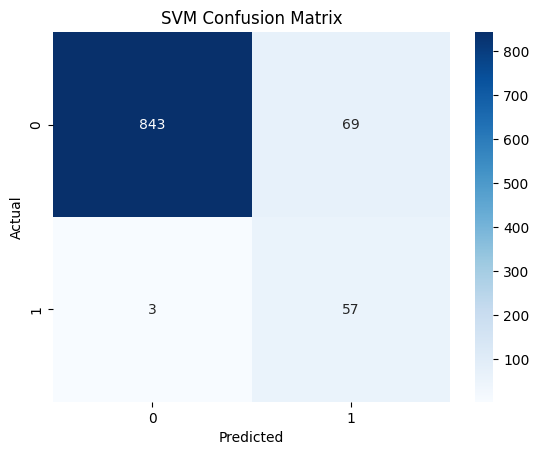

In [21]:
cm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

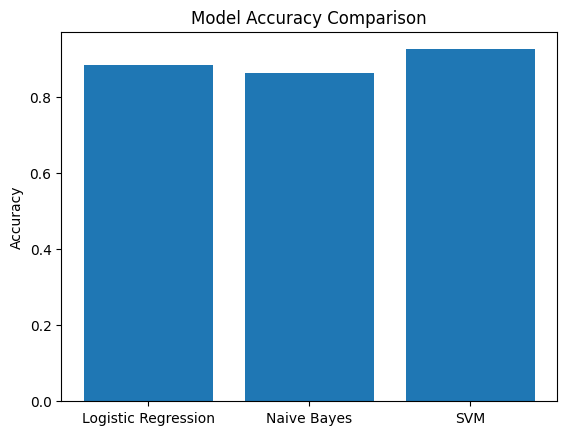

In [22]:
models = ['Logistic Regression','Naive Bayes','SVM']
accuracy = [acc_lr, acc_nb, acc_svm]

plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()